In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load datasets
df_b1 = pd.read_csv('/content/drive/MyDrive/processed_midus_b1.csv')
df_b2 = pd.read_csv('/content/drive/MyDrive/processed_midus_b2.csv')
print(f'B1 shape: {df_b1.shape}')
print(f'B2 shape: {df_b2.shape}')

B1 shape: (1028, 14)
B2 shape: (940, 14)


In [4]:
hrv_vars = ['lf_hrv', 'hf_hrv', 'rmssd', 'hr']

def plot_input_distributions(df, variables, title_prefix=''):
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 3, figsize=(15, 4*n_vars))
    for i, var in enumerate(variables):
        data_col = df[var].dropna()
        axes[i, 0].hist(data_col, bins=50, edgecolor='black', alpha=0.7)
        axes[i, 0].set_title(f'{var} - Histogram')
        axes[i, 0].set_xlabel(var)
        axes[i, 0].set_ylabel('Frequency')
        data_col.plot(kind='kde', ax=axes[i, 1])
        axes[i, 1].set_title(f'{var} - Density')
        axes[i, 1].set_xlabel(var)
        stats.probplot(data_col, dist='norm', plot=axes[i, 2])
        axes[i, 2].set_title(f'{var} - Q-Q Plot')
    fig.suptitle(title_prefix, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

def create_summary_stats(df, variables):
    summary = pd.DataFrame({
        'Variable':   variables,
        'N':          [df[v].notna().sum() for v in variables],
        'Mean':       [df[v].mean() for v in variables],
        'SD':         [df[v].std() for v in variables],
        'Skewness':   [df[v].skew() for v in variables],
        'Kurtosis':   [df[v].kurtosis() for v in variables],
        'N_Outliers': [len(df[
            (df[v] < df[v].quantile(0.25) - 1.5*stats.iqr(df[v].dropna())) |
            (df[v] > df[v].quantile(0.75) + 1.5*stats.iqr(df[v].dropna()))
        ]) for v in variables]
    })
    return summary.round(3)


Functions defined.


#B1 & B2

=== DATASET A: B1 ONLY ===


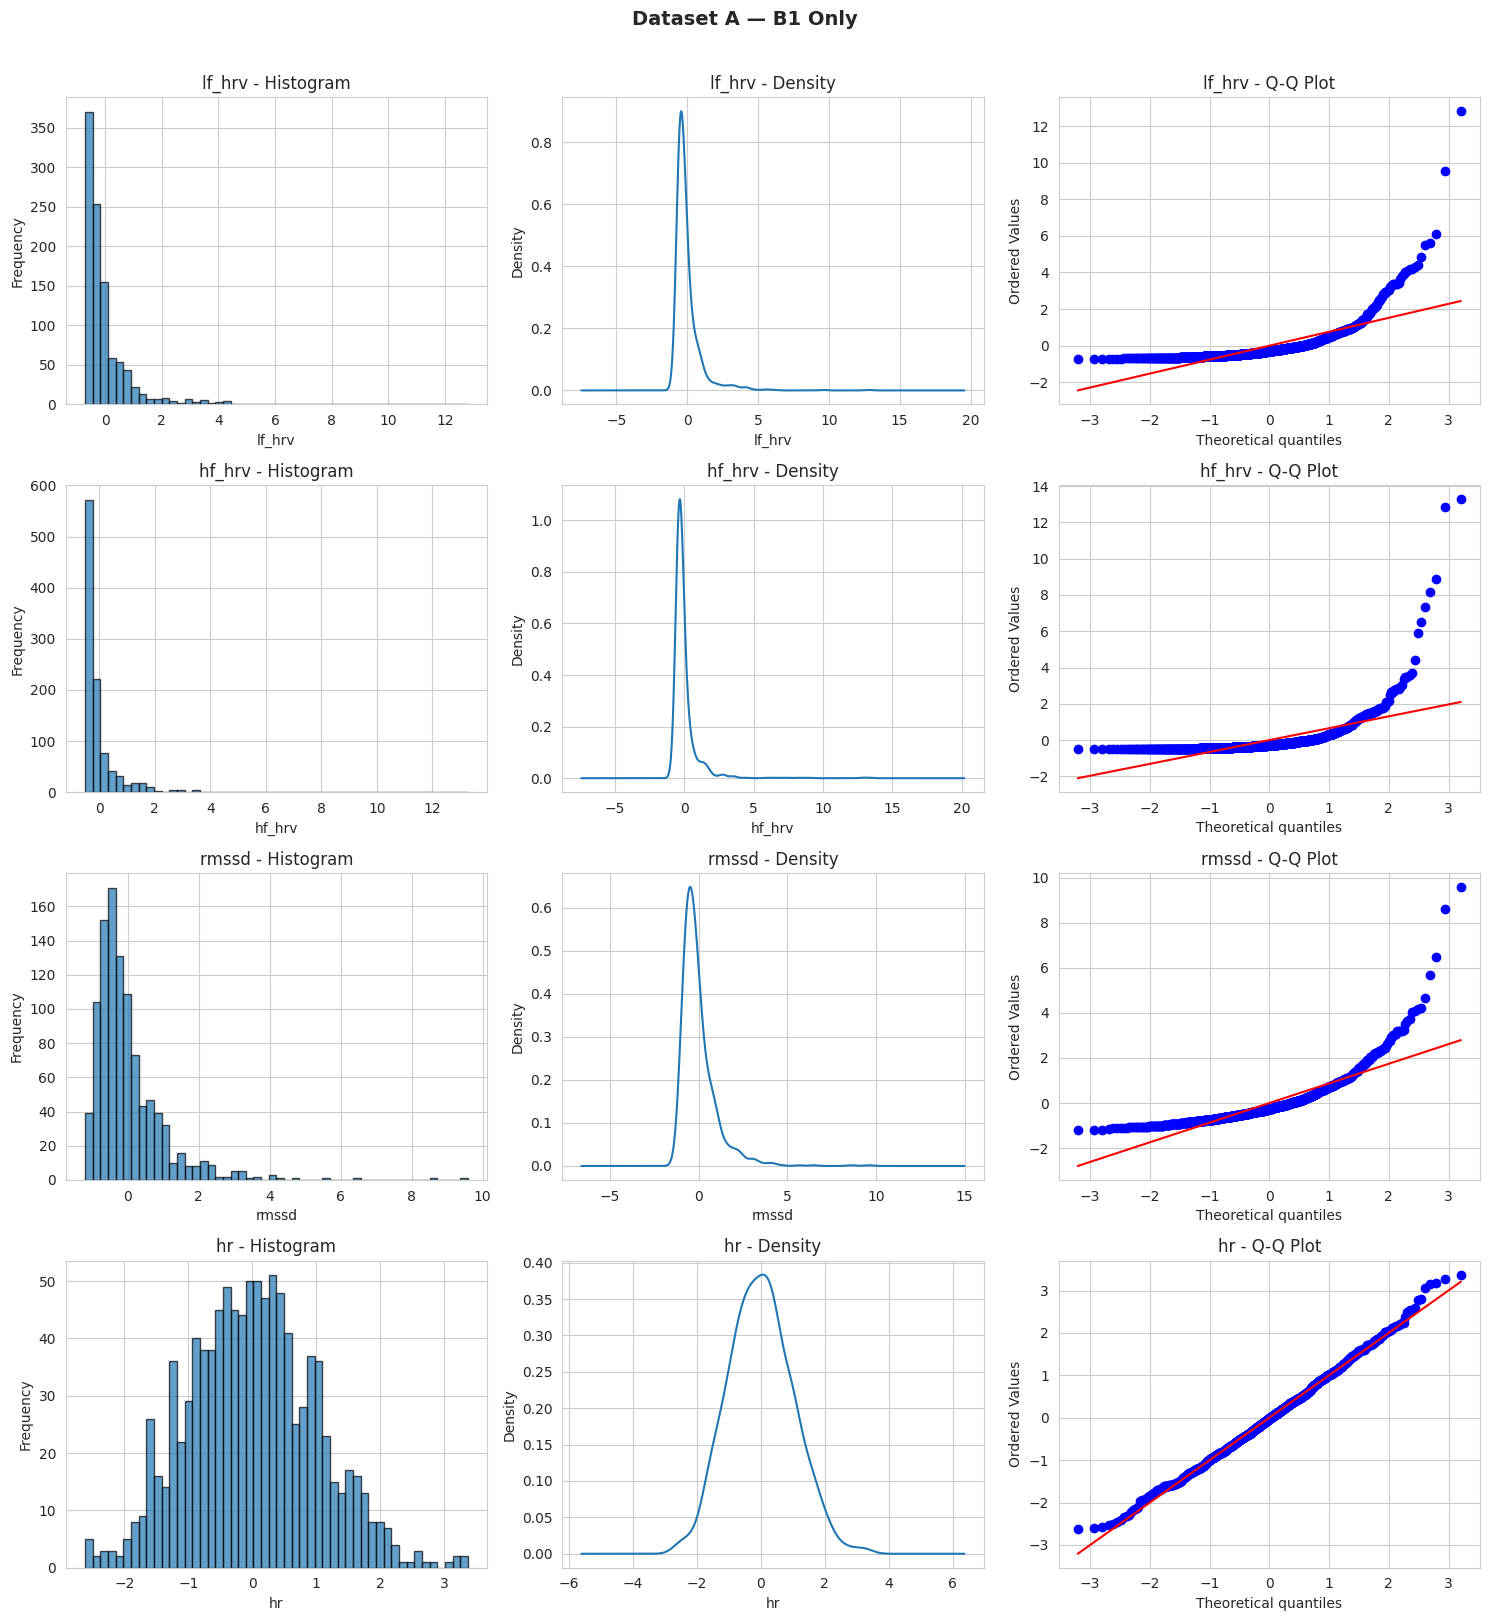

  Variable  Skewness  Kurtosis  N_Outliers
0   lf_hrv     4.857    39.791          84
1   hf_hrv     7.101    72.502         107
2    rmssd     3.097    17.613          61
3       hr     0.194    -0.009           7

=== DATASET B: B2 ONLY ===


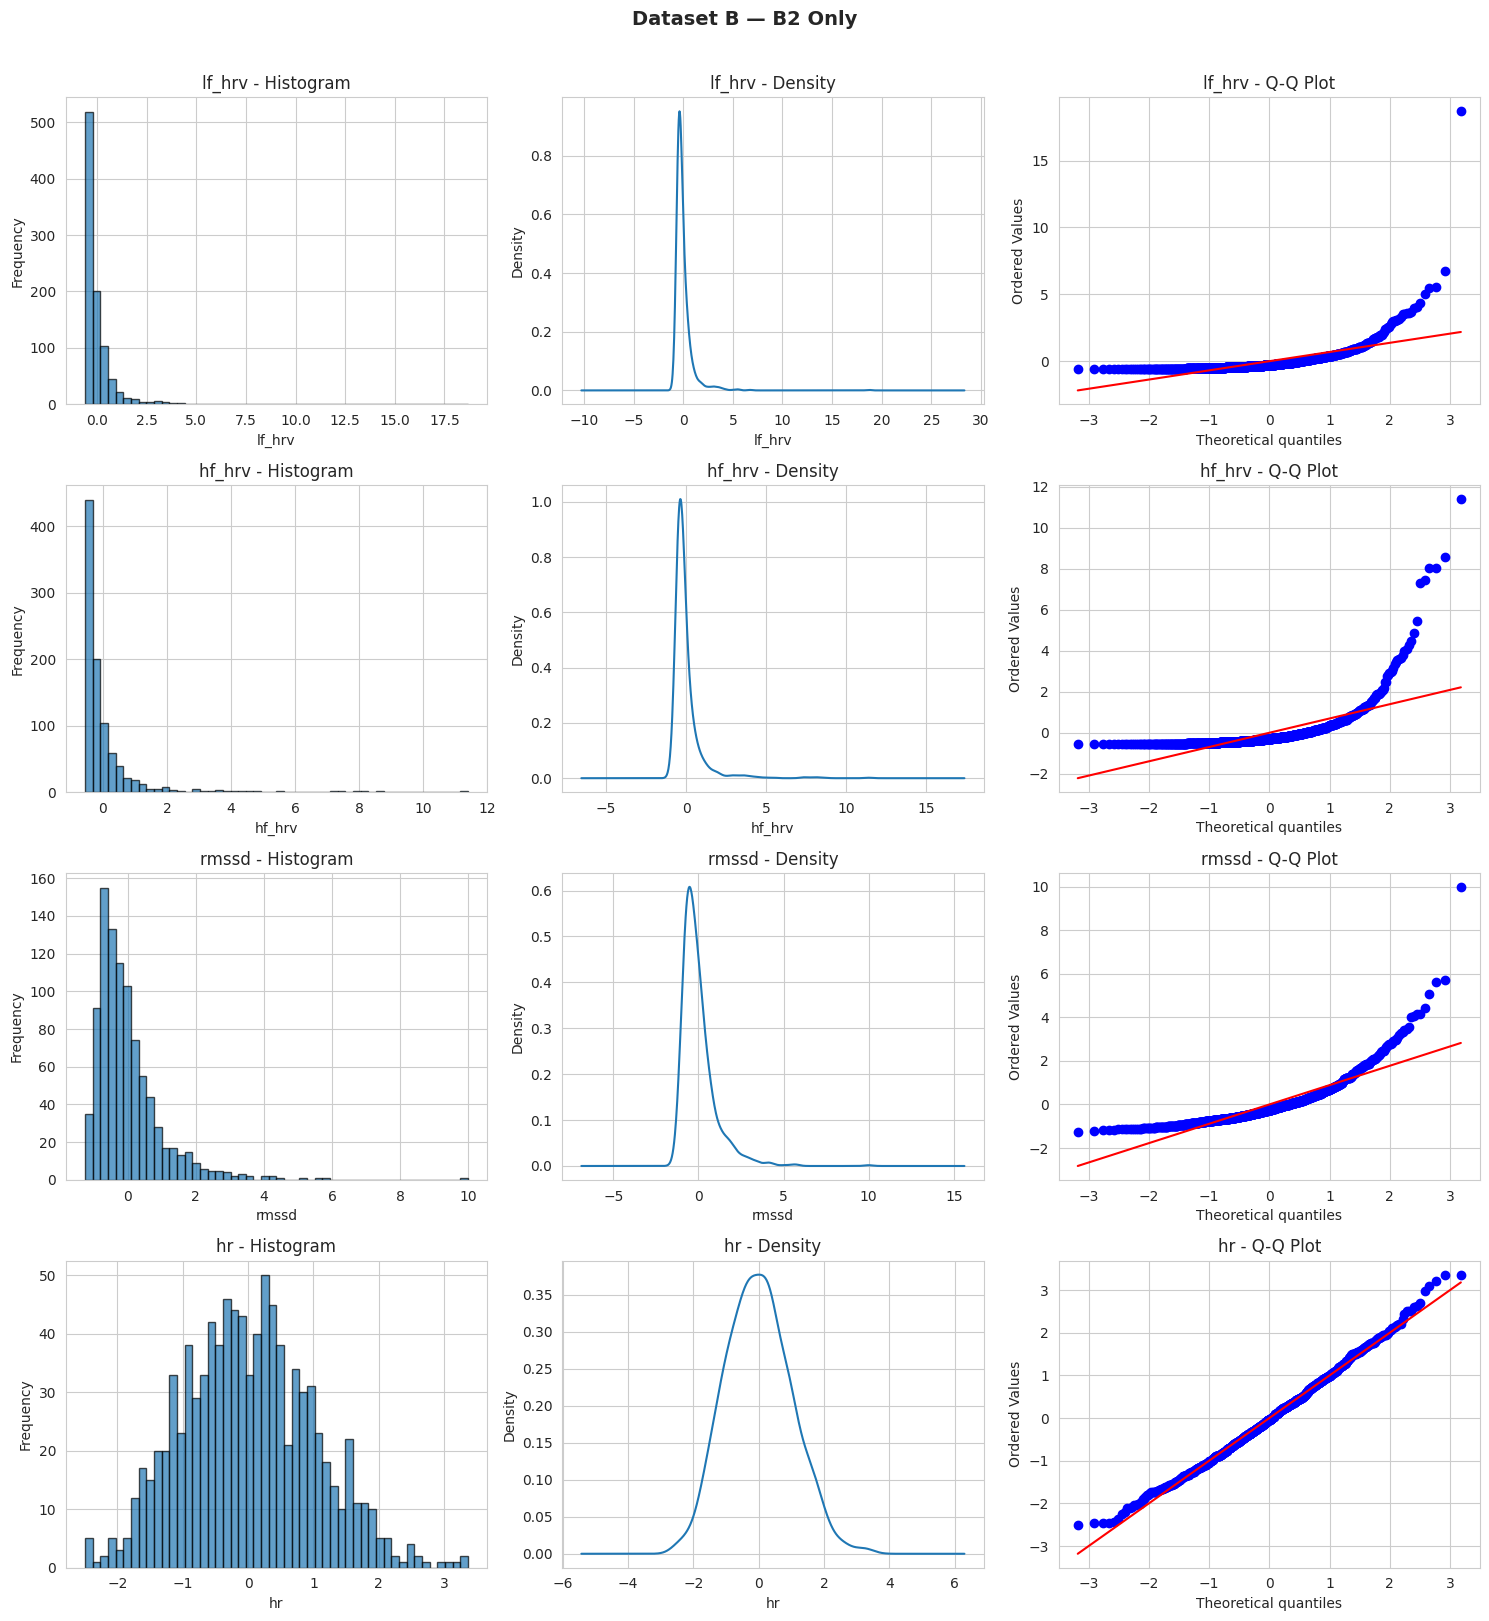

  Variable  Skewness  Kurtosis  N_Outliers
0   lf_hrv     8.695   135.302          67
1   hf_hrv     5.468    41.119          85
2    rmssd     2.761    14.820          54
3       hr     0.248    -0.050           5

=== COMPARISON: B1 vs B2 ===
  Variable  B1_Outliers  B2_Outliers  B1_Skewness  B2_Skewness
0   lf_hrv           84           67        4.857        8.695
1   hf_hrv          107           85        7.101        5.468
2    rmssd           61           54        3.097        2.761
3       hr            7            5        0.194        0.248

Total outliers — B1: 259 | B2: 211
Relative difference: 18.5%
→ B2 is cleaner. USE B2.


In [5]:
# ── B1 Distributions & Stats ──────────────────────────────────────────────
print('=== DATASET A: B1 ONLY ===')
plot_input_distributions(df_b1, hrv_vars, title_prefix='Dataset A — B1 Only')
stats_b1 = create_summary_stats(df_b1, hrv_vars)
print(stats_b1[['Variable','Skewness','Kurtosis','N_Outliers']].to_string())

# ── B2 Distributions & Stats ──────────────────────────────────────────────
print('\n=== DATASET B: B2 ONLY ===')
plot_input_distributions(df_b2, hrv_vars, title_prefix='Dataset B — B2 Only')
stats_b2 = create_summary_stats(df_b2, hrv_vars)
print(stats_b2[['Variable','Skewness','Kurtosis','N_Outliers']].to_string())

# ── Side by side comparison ───────────────────────────────────────────────
print('\n=== COMPARISON: B1 vs B2 ===')
comparison = pd.DataFrame({
    'Variable':      hrv_vars,
    'B1_Outliers':   stats_b1['N_Outliers'].values,
    'B2_Outliers':   stats_b2['N_Outliers'].values,
    'B1_Skewness':   stats_b1['Skewness'].values,
    'B2_Skewness':   stats_b2['Skewness'].values,
})
print(comparison.to_string())

b1_total = stats_b1['N_Outliers'].sum()
b2_total = stats_b2['N_Outliers'].sum()
print(f'\nTotal outliers — B1: {b1_total} | B2: {b2_total}')

rel_diff = abs(b1_total - b2_total) / max(b1_total, b2_total)
print(f'Relative difference: {rel_diff:.1%}')
if rel_diff < 0.10:
    print('→ No meaningful difference. KEEP COMBINED dataset.')
elif b1_total < b2_total:
    print('→ B1 is cleaner. USE B1.')
else:
    print('→ B2 is cleaner. USE B2.')

In [7]:
# Load the combined dataset (original pipeline output)
from google.colab import files
uploaded = files.upload()

Saving processed_midus_data.csv to processed_midus_data.csv


In [9]:
# ── Log transform on combined dataset ────────────────────────────────────
# We need raw values so reload from the original merged (pre-standardised)
# Since processed_midus_data.csv is already z-scored, we reverse-engineer:
# Just check skewness first
data = pd.read_csv("processed_midus_data.csv")
hrv_to_log = ['lf_hrv', 'hf_hrv', 'rmssd']

print('Skewness BEFORE log transform:')
print(data[hrv_to_log].skew().round(3))

Skewness BEFORE log transform:
lf_hrv    6.990
hf_hrv    6.032
rmssd     2.669
dtype: float64


In [10]:
# Apply log transform (data is z-scored so shift to positive first)
df_log = data.copy()
for var in hrv_to_log:
    min_val = df_log[var].min()
    if min_val <= 0:
        df_log[var] = np.log1p(df_log[var] - min_val + 1e-6)
    else:
        df_log[var] = np.log1p(df_log[var])


In [11]:
# Re-standardise
scaler = StandardScaler()
cols_to_scale = [c for c in df_log.select_dtypes(include=[np.number]).columns
                 if c not in ('patient_id', 'cvd_risk')]
df_log[cols_to_scale] = scaler.fit_transform(df_log[cols_to_scale])

print('\nSkewness AFTER log transform:')
print(df_log[hrv_to_log].skew().round(3))


Skewness AFTER log transform:
lf_hrv    1.745
hf_hrv    2.238
rmssd     0.829
dtype: float64



=== POST LOG TRANSFORM DISTRIBUTIONS ===


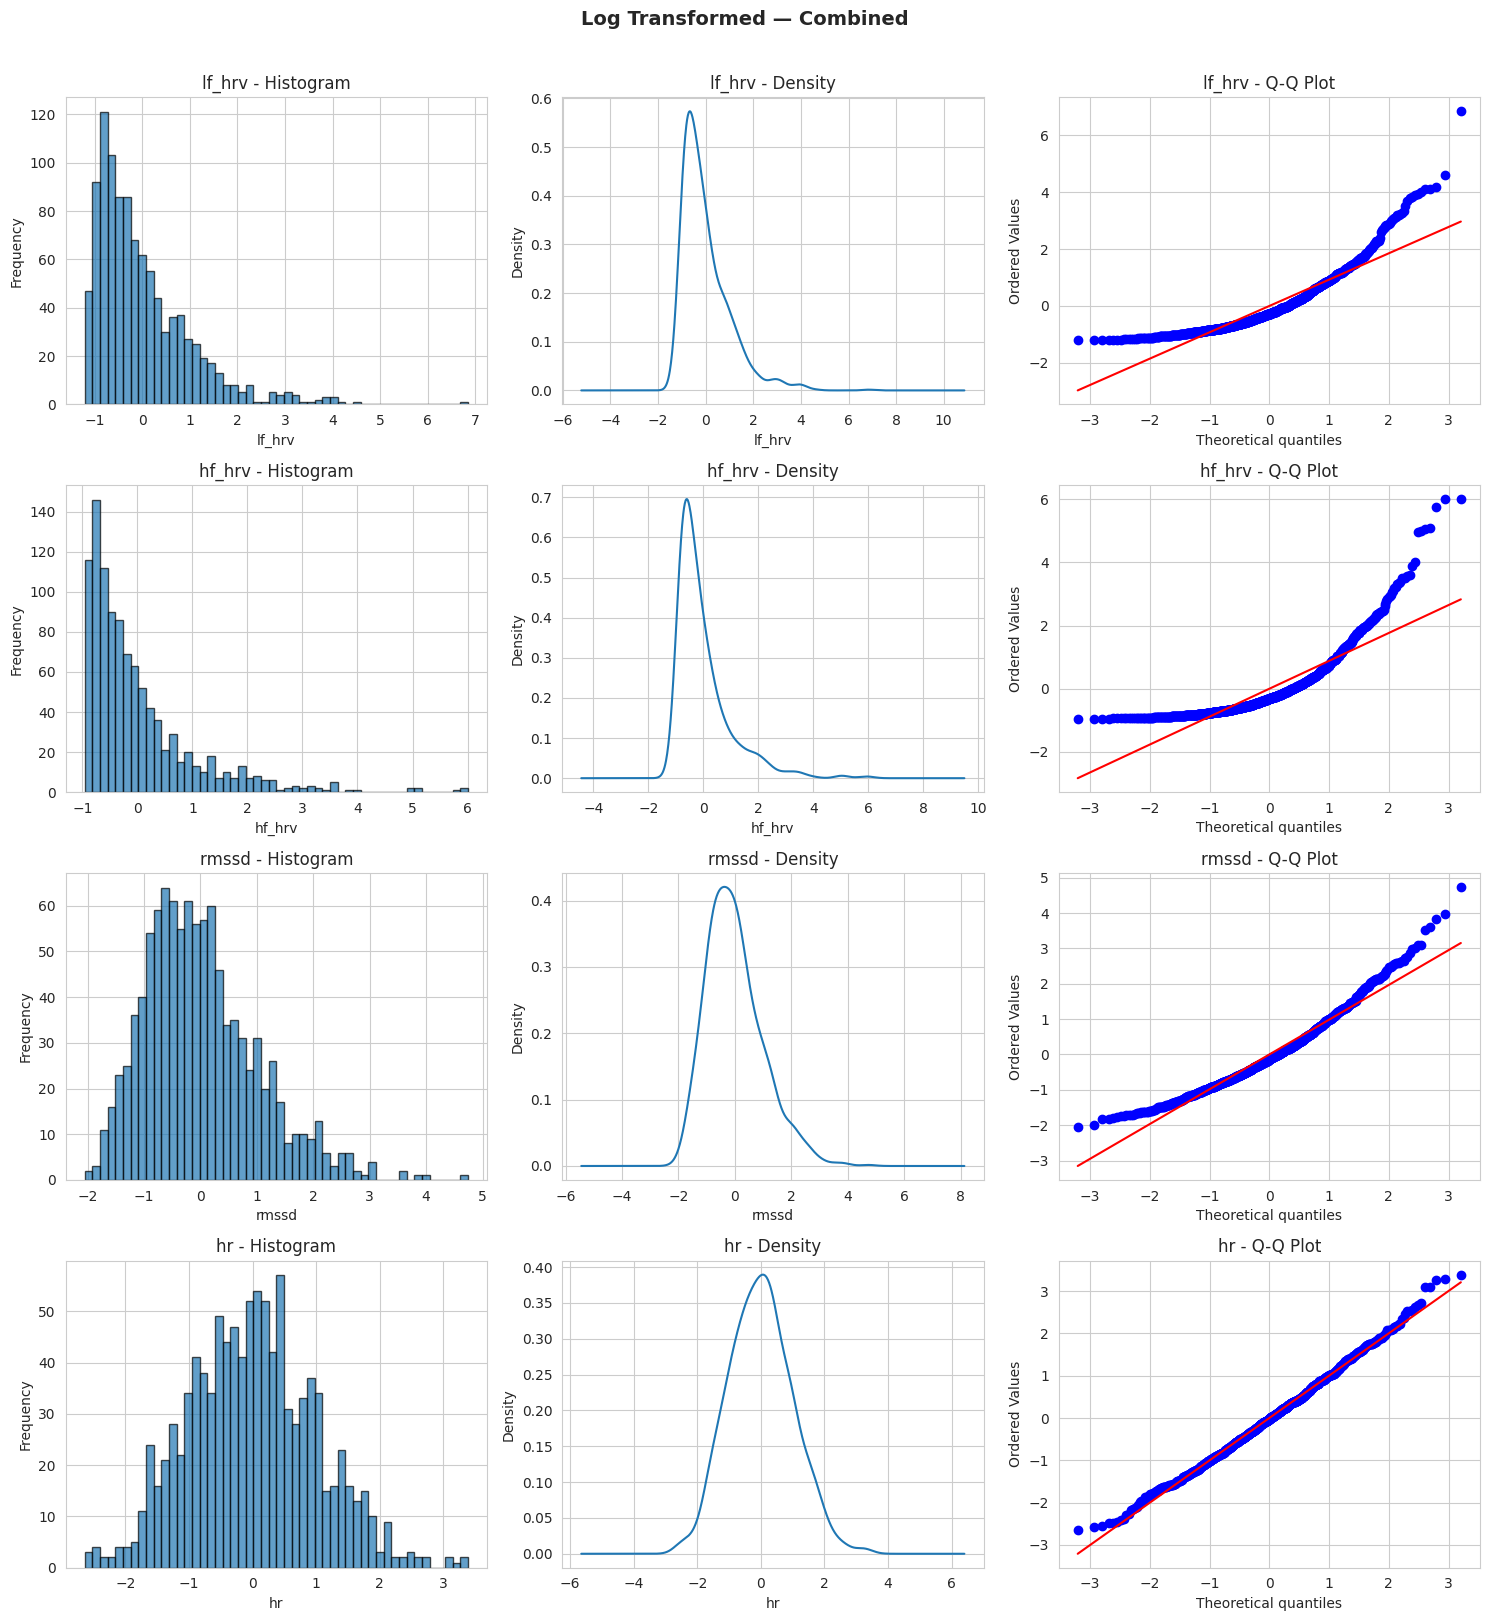

  Variable  Skewness  Kurtosis  N_Outliers
0   lf_hrv     1.745     4.466          40
1   hf_hrv     2.238     6.785          74
2    rmssd     0.829     0.922          23
3       hr     0.211    -0.004           6

Saved: processed_midus_log.csv


In [12]:
# ── Visualise post-log distributions ─────────────────────────────────────
print('\n=== POST LOG TRANSFORM DISTRIBUTIONS ===')
plot_input_distributions(df_log, hrv_vars, title_prefix='Log Transformed — Combined')
stats_log = create_summary_stats(df_log, hrv_vars)
print(stats_log[['Variable','Skewness','Kurtosis','N_Outliers']].to_string())

# Save log transformed dataset
df_log.to_csv('/content/drive/MyDrive/processed_midus_log.csv', index=False)
print('\nSaved: processed_midus_log.csv')